# The Normal Distribution

In [1]:
# Dependencies,
import numpy as np
import matplotlib.pyplot as plt

# Enable LaTeX,
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
})

Graphing the standard normal distribution,

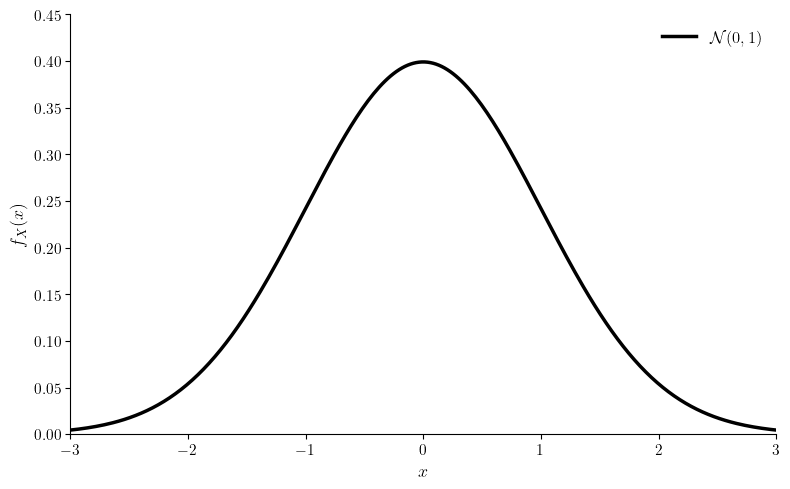

In [2]:
# Parameters,
mu = 0
sigma = 1

# Creating data,
x = np.linspace(start=-3, stop=3, num=250)
f_x = (1/(sigma*np.sqrt(2*np.pi)))*np.exp(-(x-mu)**2/(2*sigma**2))

# Graphing,
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x, f_x,linewidth=2.5,label=r"$\mathcal{N}(0,1)$", color="black")
ax.set_xlabel(r"$x$", fontsize=13)
ax.set_ylabel(r"$f_X(x)$", fontsize=13)
ax.set_xlim(-3, 3)
ax.set_ylim(0, 0.45)
ax.grid(True,linestyle="--", linewidth=0.6, alpha=0.35)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(
    axis="both",
    which="major",
    labelsize=11
)

ax.legend(
    frameon=False,
    fontsize=12,
    loc="upper right"
)

ax.grid(False)
fig.tight_layout()
plt.show()

Taking the area underneath,

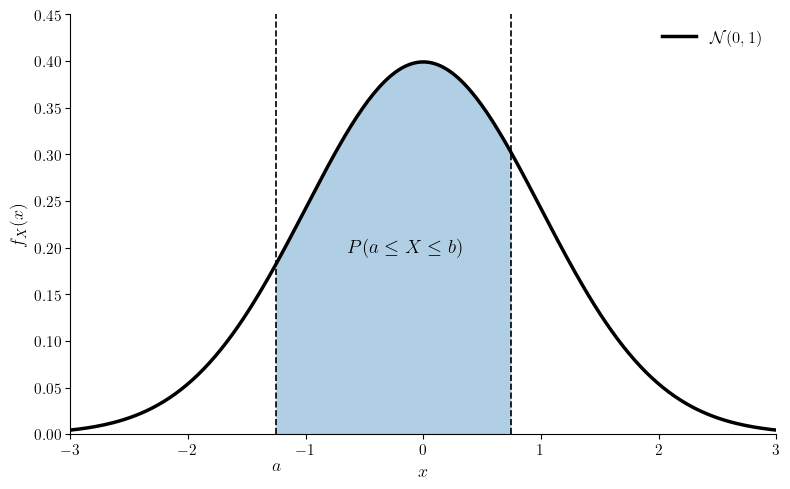

In [3]:
# Integration bounds,
a = -1.25
b = 0.75

# Graphing,
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x, f_x,linewidth=2.5,label=r"$\mathcal{N}(0,1)$", color="black")
ax.set_xlabel(r"$x$", fontsize=13)
ax.set_ylabel(r"$f_X(x)$", fontsize=13)
ax.set_xlim(-3, 3)
ax.set_ylim(0, 0.45)
ax.grid(True,linestyle="--", linewidth=0.6, alpha=0.35)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(
    axis="both",
    which="major",
    labelsize=11
)

ax.legend(
    frameon=False,
    fontsize=12,
    loc="upper right"
)

ax.grid(False)
x_fill = np.linspace(a, b, 100)
f_fill = (1/(sigma*np.sqrt(2*np.pi))) * np.exp(
    -(x_fill-mu)**2/(2*sigma**2)
)

ax.fill_between(
    x_fill,
    f_fill,
    alpha=0.35,
    label=r"$P(a \leq X \leq b)$"
)

# Mark integration limits,

ax.axvline(
    a,
    linestyle="--",
    linewidth=1.2,
    color="black"
)

ax.axvline(
    b,
    linestyle="--",
    linewidth=1.2,
    color="black"
)

# Label a and b,

ax.text(
    a,
    -0.025,
    r"$a$",
    ha="center",
    va="top",
    fontsize=13
)

ax.text(
    -0.15,
    0.2,
    r"$P(a \leq X \leq b)$",
    ha="center",
    va="center",
    fontsize=14
)

fig.tight_layout()
plt.show()

### Three Sigma Rule

In [51]:
import numpy as np
from scipy.special import factorial

def compute_series(z, n=5):
    pre_factor = np.sqrt(2/np.pi)
    n = np.arange(start=0, stop=n, step=1, dtype=int)
    summed = np.sum(((-1)**n*z**(2*n+1))/(2**n*(2*n+1)*factorial(n)))
    return pre_factor*summed

In [61]:
compute_series(z=3, n=30)

0.9391895944208257

In [62]:
import mpmath as mp

def compute_series(z, n=100):
    mp.mp.dps = 50

    total = mp.mpf(0)

    for k in range(n):
        term = (
            (-1)**k * mp.mpf(z)**(2*k + 1)
            / (2**k * (2*k + 1) * mp.factorial(k))
        )
        total += term

    return mp.sqrt(2 / mp.pi) * total

print(compute_series(3, 100))

0.99730020393673981094669637046481004524434126368324
